In [1]:
import sys
sys.path.append('..')
import torch
import torch.nn.functional as F
from tqdm import tqdm
import logging
from datetime import datetime
import copy
import os

import matplotlib.pyplot as plt
from matplotlib import colors

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel

In [2]:
ARC_COLORS = [
    '#000000', '#0074D9', '#FF4136', '#2ECC40',
    '#FFDC00', '#AAAAAA', '#F012BE', '#FF851B',
    '#7FDBFF', '#870C25'
]

cmap = colors.ListedColormap(ARC_COLORS)
norm = colors.BoundaryNorm(range(11), cmap.N)

In [3]:
def pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).float().mean().item()

def task_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).all(dim=(1, 2)).float().mean().item()

def grid_to_string(grid):
    if hasattr(grid, 'cpu'):
        grid = grid.cpu().numpy()
    return '\n'.join(' '.join(str(int(cell)) for cell in row) for row in grid)

In [4]:
def show_triplet(input_grid, gt_grid, pred_grid, title=""):
    input_grid = input_grid.cpu().numpy()
    gt_grid = gt_grid.cpu().numpy()
    pred_grid = pred_grid.cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    axs[0].imshow(input_grid, cmap=cmap, norm=norm)
    axs[0].set_title("Input")

    axs[1].imshow(gt_grid, cmap=cmap, norm=norm)
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred_grid, cmap=cmap, norm=norm)
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [5]:
def save_triplet(input_grid, gt_grid, pred_grid, save_path, title):
    input_grid = input_grid.cpu().numpy()
    gt_grid = gt_grid.cpu().numpy()
    pred_grid = pred_grid.cpu().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(9, 3))

    axs[0].imshow(input_grid, cmap=cmap, norm=norm)
    axs[0].set_title("Input")

    axs[1].imshow(gt_grid, cmap=cmap, norm=norm)
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred_grid, cmap=cmap, norm=norm)
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

In [6]:
def safe_tta(model, sx, sy, qx, steps=10, lr=5e-4):
    local_model = copy.deepcopy(model)
    local_model.train()

    params = list(local_model.decoder.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)

    for _ in range(steps):
        optimizer.zero_grad()

        task_tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, task_tokens)

        loss = F.cross_entropy(pred, sy.squeeze(1).long())
        loss.backward()

        torch.nn.utils.clip_grad_norm_(params, 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        task_tokens = local_model.task_encoder(sx_feat, sy_feat)

        qx_feat = local_model.encoder(qx)
        return local_model.decoder(qx_feat, task_tokens)

In [7]:
MODEL_PATH = "/home/saij/ml/arc-meta/models/arc_best.pt"
DATA_DIR = "/home/saij/ml/arc-meta/data/evaluation"
BATCH_SIZE = 4
OUTPUT_DIR = "/home/saij/ml/arc-meta/logs"

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
log_dir = os.path.join(OUTPUT_DIR, f"eval_{timestamp}")
img_dir = os.path.join(log_dir, "images")

os.makedirs(img_dir, exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(os.path.join(log_dir, "eval.log")),
        logging.StreamHandler()
    ]
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [8]:
dataset = ARCTaskDataset(DATA_DIR)
loader = get_arc_loader(dataset, batch_size=BATCH_SIZE)

model = ARCModel().to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)
model.eval()

ARCModel(
  (encoder): GridEncoder(
    (embed): Embedding(10, 128)
    (conv): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (task_encoder): TaskEncoder(
    (proj): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): Decoder(
    (pre_conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (cross_attn): CrossAttentionBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  

  0%|          | 0/100 [00:00<?, ?it/s]


Task 1 | Sample 0
Pixel Acc: 0.9878 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
8 0 0 0 5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 3 3 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 3 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

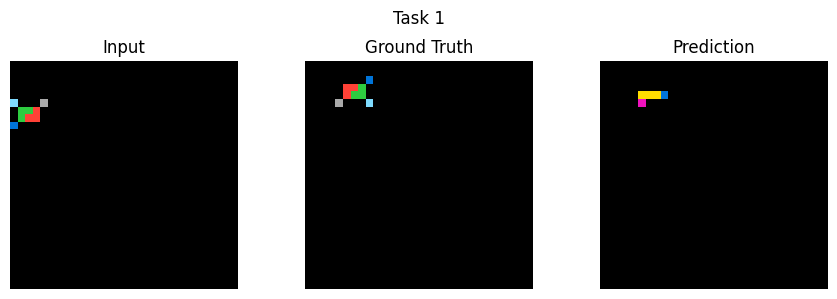


Task 2 | Sample 0
Pixel Acc: 0.9822 | Task Acc: 0.0000

Input:
 2 1 0 0 0 1 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

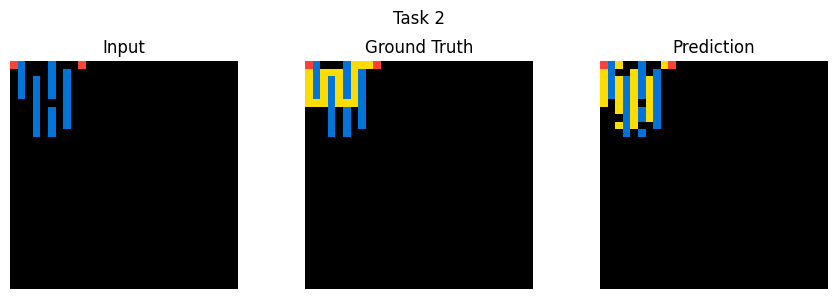


Task 3 | Sample 0
Pixel Acc: 0.8533 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 5 5 5 0 5 5 5 0 5 5 5 0 5 5 5 0 0 0 0 0 0 0 0
0 2 1 2 2 0 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 0 0 0 0 0 0 0
0 8 1 4 4 0 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 0 0 0 0 0 0 0
0 3 1 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 1 3 1 0 0 5 5 5 0 5 5 5 0 5 5 5 0 5 5 5 0 0 0 0 0 0 0 0
0 8 1 1 1 0 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 5 5 5 0 5 5 5 0 5 5 5 0 5 5 5 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 5 5 5 0 5 5 5 0 5 5 5 0 5 5 5 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 5 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 5 0 5 0 5 0 5 0 5 0 5

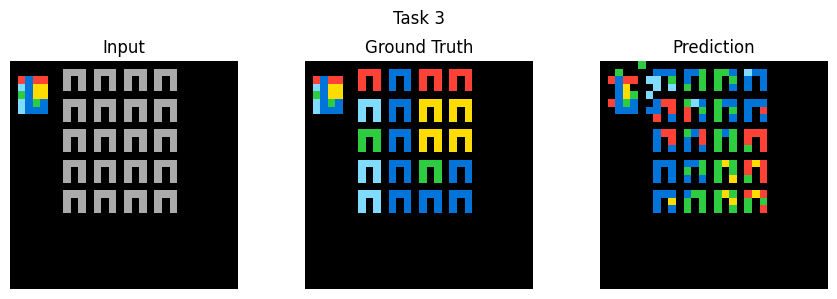


Task 4 | Sample 0
Pixel Acc: 0.9889 | Task Acc: 0.0000

Input:
 0 8 8 0 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
8 8 8 8 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 8 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 8 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

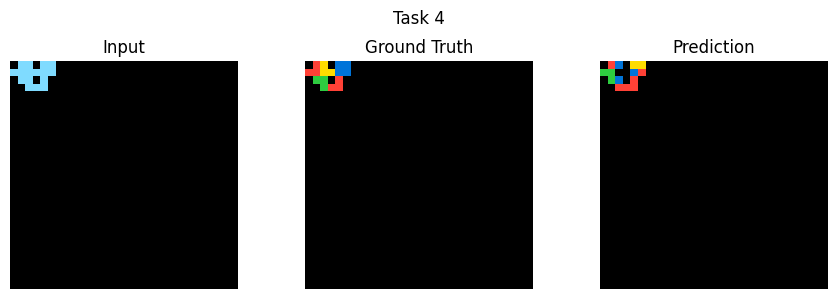

  1%|          | 1/100 [00:08<13:46,  8.35s/it]


Task 5 | Sample 0
Pixel Acc: 0.7800 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 8 2 8 0 1 8 1 1 8 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 8 2 2 0 8 1 1 1 1 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 2 8 8 0 1 8 1 1 8 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 8 2 8 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0
0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

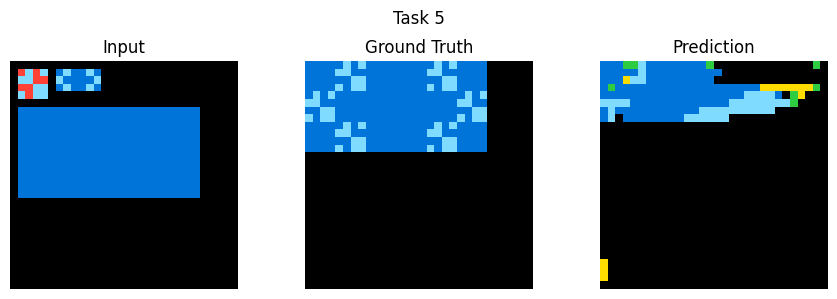


Task 6 | Sample 0
Pixel Acc: 0.9861 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 2 2 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

  2%|▏         | 2/100 [00:09<07:07,  4.36s/it]


Task 8 | Sample 0
Pixel Acc: 0.9933 | Task Acc: 0.0000

Input:
 4 3 0 0 0 2 0 0 0 8 3 2 1 0 0 0 0 2 0 8 0 0 0 2 8 0 0 0 0 0
6 0 0 0 0 2 0 0 0 0 0 2 0 0 7 4 0 2 0 7 4 0 4 2 0 9 0 5 0 0
0 0 0 0 0 2 0 9 1 0 5 2 0 6 6 0 0 2 0 0 0 1 0 2 0 0 0 0 3 0
0 0 0 0 0 2 0 0 8 0 0 2 0 0 2 0 0 2 0 0 0 3 0 2 4 0 1 0 0 0
0 0 0 0 0 2 4 0 0 9 0 2 0 9 0 2 5 2 0 0 3 7 0 2 0 0 0 4 0 0
2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0
6 0 0 0 0 2 6 0 5 0 0 2 0 0 0 0 0 2 0 6 0 0 0 2 0 0 0 0 0 0
0 0 7 0 0 2 0 0 3 0 0 2 9 0 0 0 0 2 0 0 0 0 0 2 0 0 7 0 0 0
7 0 8 3 0 2 0 0 4 4 6 2 0 0 9 7 7 2 2 0 9 0 0 2 0 0 6 0 0 0
0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 0 3 2 0 0 4 0 0 2 0 0 5 0 0 0
0 0 3 0 3 2 0 0 0 0 0 2 0 0 0 0 0 2 0 0 0 0 0 2 5 5 0 0 0 0
2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0
0 0 6 4 0 2 0 0 8 0 8 2 0 0 0 0 0 2 0 0 8 0 6 2 0 0 0 0 0 0
0 3 0 0 7 2 0 0 0 0 0 2 1 0 0 1 6 2 0 0 0 0 0 2 0 4 0 0 3 0
0 0 0 0 0 2 8 0 0 0 0 2 0 0 1 1 0 2 0 9 0 0 0 2 0 2 0 8 0 0
0 0 5 0 0 2 0 0 8 8 0 2 0 0 0 0 0 2

  3%|▎         | 3/100 [00:11<04:57,  3.07s/it]


Task 12 | Sample 0
Pixel Acc: 0.5344 | Task Acc: 0.0000

Input:
 5 4 3 2 4 3 2 1 5 4 3 2 4 3 2 1 5 4 3 2 4 3 2 1 5 4 3 0 0 0
4 5 6 7 7 8 9 1 4 5 6 7 7 8 9 1 4 5 6 7 7 8 9 1 4 5 6 0 0 0
3 6 9 3 1 4 7 1 3 6 9 3 1 4 7 1 3 6 9 3 1 4 7 1 3 6 9 0 0 0
2 7 3 8 4 0 0 0 0 7 3 8 4 9 5 1 2 7 3 8 4 9 5 1 2 7 3 0 0 0
4 7 1 4 1 0 0 0 0 7 1 4 1 4 7 1 4 7 1 4 1 4 7 1 4 7 1 0 0 0
3 8 4 9 4 0 0 0 0 8 4 9 4 9 5 1 3 8 4 9 4 9 5 1 3 8 4 0 0 0
2 0 0 0 0 0 0 0 0 9 7 5 7 5 3 1 2 9 7 5 7 5 3 1 2 9 7 0 0 0
1 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 0
5 0 0 0 0 0 2 1 5 4 3 2 4 3 2 1 5 4 3 2 4 3 2 1 0 0 3 0 0 0
4 0 0 0 0 0 9 1 4 5 6 7 7 8 9 1 4 5 6 7 7 8 9 1 0 0 6 0 0 0
3 0 0 0 0 0 7 1 3 6 9 3 1 4 7 1 3 6 9 3 1 4 7 1 0 0 9 0 0 0
2 0 0 0 0 0 5 1 2 7 3 8 4 0 0 0 0 0 0 8 4 9 5 1 2 7 3 0 0 0
4 7 1 4 1 4 7 1 4 7 1 4 1 0 0 0 0 0 0 4 1 4 7 1 4 7 1 0 0 0
3 8 4 9 4 9 5 1 3 8 4 9 4 9 5 1 3 8 4 9 4 9 5 1 3 8 4 0 0 0
2 9 7 5 7 5 3 1 2 9 7 5 7 5 3 1 2 9 7 5 7 5 3 1 2 9 7 0 0 0
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

...

 98%|█████████▊| 98/100 [02:40<00:05,  2.84s/it]


Task 393 | Sample 0
Pixel Acc: 0.8833 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

 99%|█████████▉| 99/100 [02:42<00:02,  2.48s/it]


Task 396 | Sample 0
Pixel Acc: 0.9856 | Task Acc: 0.0000

Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 2 2 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

100%|██████████| 100/100 [02:43<00:00,  1.64s/it]


In [9]:
total_pixel_acc = 0
total_task_acc = 0
count = 0

MAX_VIS = 5  # limit display

for batch in tqdm(loader):

    if batch["query_y"] is None:
        continue

    support_x = batch["support_x"].to(device)
    support_y = batch["support_y"].to(device)
    query_x = batch["query_x"].to(device)
    query_y = batch["query_y"].to(device)

    support_mask = batch["support_mask"]
    query_mask = batch["query_mask"]

    B = support_x.shape[0]

    for b in range(B):

        s_len = int(support_mask[b].sum().item())
        q_len = int(query_mask[b].sum().item())

        sx = support_x[b, :s_len].long()
        sy = support_y[b, :s_len].long()
        qx = query_x[b, :q_len].long()
        qy = query_y[b, :q_len].long()

        if sx.numel() == 0 or qx.numel() == 0:
            continue

        pred = safe_tta(model, sx, sy, qx)

        h, w = qy.shape[-2:]
        pred = pred[:, :, :h, :w]

        pred_classes = pred.argmax(dim=1)

        p_acc = pixel_accuracy(pred, qy)
        t_acc = task_accuracy(pred, qy)

        total_pixel_acc += p_acc
        total_task_acc += t_acc
        count += 1

        for i in range(qx.shape[0]):

            print("\n" + "=" * 50)
            print(f"Task {count} | Sample {i}")
            print(f"Pixel Acc: {p_acc:.4f} | Task Acc: {t_acc:.4f}")

            print("\nInput:\n", grid_to_string(qx[i][0]))
            print("\nGT:\n", grid_to_string(qy[i][0]))
            print("\nPred:\n", grid_to_string(pred_classes[i]))

            # show inline
            if count <= MAX_VIS:
                show_triplet(
                    qx[i][0],
                    qy[i][0],
                    pred_classes[i],
                    title=f"Task {count}"
                )

            # save image
            save_path = os.path.join(
                img_dir,
                f"task_{count}_sample_{i}.png"
            )

            save_triplet(
                qx[i][0],
                qy[i][0],
                pred_classes[i],
                save_path,
                title=f"Task {count} | Pixel={p_acc:.3f}"
            )

In [10]:
if count > 0:
    print("\n" + "=" * 50)
    print(f"Final Pixel Accuracy: {total_pixel_acc / count:.4f}")
    print(f"Final Task Accuracy:  {total_task_acc / count:.4f}")
    print("=" * 50)
else:
    print("No tasks evaluated.")


Final Pixel Accuracy: 0.9186
Final Task Accuracy:  0.0025


In [ ]:
import argparse
import torch
import torch.nn.functional as F
from tqdm import tqdm
import logging
from datetime import datetime
import copy

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel   # match your training


# =========================
# Metrics
# =========================
def pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).float().mean().item()


def task_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).all(dim=(1, 2)).float().mean().item()


# =========================
# SAFE TTA (FIXED)
# =========================
def safe_tta(model, sx, sy, qx, steps=10, lr=5e-4):
    local_model = copy.deepcopy(model)
    local_model.train()

    params = list(local_model.decoder.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    # detach encoder features (CRITICAL FIX)
    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)

    for _ in range(steps):
        optimizer.zero_grad()

        task_tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, task_tokens)

        loss = F.cross_entropy(pred, sy.squeeze(1).long())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        task_tokens = local_model.task_encoder(sx_feat, sy_feat)

        qx_feat = local_model.encoder(qx)
        return local_model.decoder(qx_feat, task_tokens)


# =========================
# Main
# =========================
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--model_path", type=str, required=True)
    parser.add_argument("--data_dir", type=str, default="data/evaluation")
    parser.add_argument("--batch_size", type=int, default=4)
    args = parser.parse_args()

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.FileHandler(f"eval_fixed_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"),
            logging.StreamHandler()
        ]
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    logging.info(f"Device: {device}")

    dataset = ARCTaskDataset(args.data_dir)
    loader = get_arc_loader(dataset, batch_size=args.batch_size)

    model = ARCModel().to(device)

    model.load_state_dict(torch.load(args.model_path, map_location=device))
    model.eval()

    total_pixel_acc = 0
    total_task_acc = 0
    count = 0

    logging.info("Starting evaluation...")

    for batch in tqdm(loader):

        if batch["query_y"] is None:
            continue

        support_x = batch["support_x"].to(device)
        support_y = batch["support_y"].to(device)
        query_x = batch["query_x"].to(device)
        query_y = batch["query_y"].to(device)

        support_mask = batch["support_mask"]
        query_mask = batch["query_mask"]

        B = support_x.shape[0]

        for b in range(B):

            # ✅ SAFE slicing (NO boolean indexing)
            s_len = int(support_mask[b].sum().item())
            q_len = int(query_mask[b].sum().item())

            sx = support_x[b, :s_len].long()
            sy = support_y[b, :s_len].long()
            qx = query_x[b, :q_len].long()
            qy = query_y[b, :q_len].long()

            if sx.numel() == 0 or qx.numel() == 0:
                continue

            # =========================
            # SAFE TTA
            # =========================
            pred = safe_tta(model, sx, sy, qx)

            # =========================
            # CRITICAL: crop output
            # =========================
            h, w = qy.shape[-2:]
            pred = pred[:, :, :h, :w]

            # =========================
            # Metrics
            # =========================
            p_acc = pixel_accuracy(pred, qy)
            t_acc = task_accuracy(pred, qy)

            total_pixel_acc += p_acc
            total_task_acc += t_acc
            count += 1

            logging.info(f"Task {count}: Pixel={p_acc:.4f}, Task={t_acc:.4f}")

    if count > 0:
        logging.info("=" * 50)
        logging.info(f"Pixel Accuracy: {total_pixel_acc / count:.4f}")
        logging.info(f"Task Accuracy:  {total_task_acc / count:.4f}")
        logging.info("=" * 50)
    else:
        logging.info("No tasks evaluated.")

In [16]:
# =========================
# ARC EVAL WITH TTA (SINGLE CELL)
# =========================

import torch
import torch.nn.functional as F
from tqdm import tqdm
import copy
from pathlib import Path

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel

# =========================
# CONFIG (EDIT HERE)
# =========================
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "models").exists() and (PROJECT_ROOT.parent / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_PATH = PROJECT_ROOT / "models" / "arc_best.pt"
DATA_DIR = PROJECT_ROOT / "data" / "evaluation"
BATCH_SIZE = 4

TTA_STEPS = 10
TTA_LR = 5e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# Metrics
# =========================
def pixel_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).float().mean().item()


def task_accuracy(pred, target):
    pred = pred.argmax(dim=1)
    target = target.squeeze(1)
    return (pred == target).all(dim=(1, 2)).float().mean().item()


# =========================
# TTA
# =========================
def safe_tta(model, sx, sy, qx, steps=TTA_STEPS, lr=TTA_LR):
    local_model = copy.deepcopy(model)
    local_model.train()

    optimizer = torch.optim.Adam(local_model.decoder.parameters(), lr=lr)

    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        qx_feat = local_model.encoder(qx)

    for _ in range(steps):
        optimizer.zero_grad()

        tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, tokens)

        loss = F.cross_entropy(pred, sy.squeeze(1).long())
        loss.backward()

        torch.nn.utils.clip_grad_norm_(local_model.decoder.parameters(), 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(qx_feat, tokens)

    return pred
print(f"Device: {DEVICE}")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model checkpoint not found: {MODEL_PATH}")
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Evaluation data directory not found: {DATA_DIR}")

dataset = ARCTaskDataset(str(DATA_DIR))
loader = get_arc_loader(dataset, batch_size=BATCH_SIZE)

model = ARCModel().to(DEVICE)
model = ARCModel().to(DEVICE)
checkpoint = torch.load(str(MODEL_PATH), map_location=DEVICE)

# Support both raw state_dict and full training checkpoint formats
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
else:
    state_dict = checkpoint

# Handle DataParallel checkpoints if present
if isinstance(state_dict, dict) and any(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

try:
    model.load_state_dict(state_dict, strict=True)
except RuntimeError as e:
    print(f"Warning: strict load failed ({e}). Falling back to strict=False.")
    model.load_state_dict(state_dict, strict=False)

model.eval()
print(f"Loaded {len(dataset)} tasks")

# =========================
# Evaluation
# =========================
total_pixel_acc = 0
total_task_acc = 0
count = 0

print("\nStarting evaluation with TTA...\n")

for batch in tqdm(loader):

    if batch["query_y"] is None:
        continue

    support_x = batch["support_x"].to(DEVICE)
    support_y = batch["support_y"].to(DEVICE)
    query_x = batch["query_x"].to(DEVICE)
    query_y = batch["query_y"].to(DEVICE)

    support_mask = batch["support_mask"]
    query_mask = batch["query_mask"]

    B = support_x.shape[0]

    for b in range(B):

        s_len = int(support_mask[b].sum().item())
        q_len = int(query_mask[b].sum().item())

        sx = support_x[b, :s_len]
        sy = support_y[b, :s_len]
        qx = query_x[b, :q_len]
        qy = query_y[b, :q_len]

        if sx.numel() == 0 or qx.numel() == 0:
            continue

        # =========================
        # TTA
        # =========================
        pred = safe_tta(model, sx, sy, qx)

        # =========================
        # Crop
        # =========================
        h, w = qy.shape[-2:]
        pred = pred[:, :, :h, :w]

        # =========================
        # Metrics
        # =========================
        p_acc = pixel_accuracy(pred, qy)
        t_acc = task_accuracy(pred, qy)

        total_pixel_acc += p_acc
        total_task_acc += t_acc
        count += 1

        print(f"Task {count}: Pixel={p_acc:.4f}, Task={t_acc:.4f}")


# =========================
# Final Results
# =========================
print("\n" + "="*50)

if count > 0:
    print(f"Pixel Accuracy: {total_pixel_acc / count:.4f}")
    print(f"Task Accuracy:  {total_task_acc / count:.4f}")
else:
    print("No tasks evaluated.")

print("="*50)

Device: cuda
Loaded 400 tasks

Starting evaluation with TTA...



  0%|          | 0/100 [00:00<?, ?it/s]

Task 1: Pixel=0.9778, Task=0.0000
Task 2: Pixel=0.9622, Task=0.0000


  1%|          | 1/100 [00:01<02:03,  1.25s/it]

Task 3: Pixel=0.8556, Task=0.0000
Task 4: Pixel=0.8933, Task=0.0000
Task 5: Pixel=0.7911, Task=0.0000
Task 6: Pixel=0.9111, Task=0.0000


...

Task 391: Pixel=0.9111, Task=0.0000
Task 392: Pixel=0.9233, Task=0.0000
Task 393: Pixel=0.9811, Task=0.0000
Task 394: Pixel=0.9944, Task=0.0000


 99%|█████████▉| 99/100 [00:59<00:00,  2.02it/s]

Task 395: Pixel=0.9644, Task=0.0000
Task 396: Pixel=0.9867, Task=0.0000
Task 397: Pixel=0.9578, Task=0.0000
Task 398: Pixel=0.9756, Task=0.0000


100%|██████████| 100/100 [01:00<00:00,  1.65it/s]

Task 399: Pixel=0.9833, Task=0.0000
Task 400: Pixel=0.5978, Task=0.0000

Pixel Accuracy: 0.9286
Task Accuracy:  0.0025


In [26]:
# =========================
# ARC EVAL WITH TTA + BEAM (NOTEBOOK CELL)
# =========================

import torch
import torch.nn.functional as F
from tqdm import tqdm
import copy
from pathlib import Path

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel

# =========================
# CONFIG
# =========================
MODEL_PATH = "models/arc_best.pt"
DATA_DIR = "data/evaluation"
BATCH_SIZE = 4

TTA_STEPS = 10
TTA_LR = 0.001
TTA_RUNS = 3
BEAM_SIZE = 5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# Metrics
# =========================
def pixel_accuracy(pred, target):
    pred = pred.squeeze(0)
    target = target.squeeze(0).squeeze(0)
    return (pred == target).float().mean().item()


def task_accuracy(pred, target):
    pred = pred.squeeze(0)
    target = target.squeeze(0).squeeze(0)
    return float(torch.all(pred == target))


def grid_to_string(grid):
    if isinstance(grid, torch.Tensor):
        grid = grid.detach().cpu()
        if grid.ndim == 3 and grid.shape[0] == 1:
            grid = grid.squeeze(0)
        grid = grid.numpy()
    return "\n".join(" ".join(str(int(cell)) for cell in row) for row in grid)


COLOR_TILES = {
    0: "⬛",
    1: "🟦",
    2: "🟥",
    3: "🟩",
    4: "🟨",
    5: "⬜",
    6: "🟪",
    7: "🟧",
    8: "🟦",
    9: "🟫",
}


def grid_to_color_string(grid):
    if isinstance(grid, torch.Tensor):
        grid = grid.detach().cpu()
        if grid.ndim == 3 and grid.shape[0] == 1:
            grid = grid.squeeze(0)
        grid = grid.numpy()

    lines = []
    for row in grid:
        lines.append("".join(COLOR_TILES.get(int(cell), "⬛") for cell in row))
    return "\n".join(lines)


# =========================
# TTA
# =========================
def safe_tta(model, sx, sy, qx):
    local_model = copy.deepcopy(model)
    local_model.train()

    optimizer = torch.optim.Adam(local_model.decoder.parameters(), lr=TTA_LR)

    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        qx_feat = local_model.encoder(qx)

    for _ in range(TTA_STEPS):
        optimizer.zero_grad()

        tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, tokens)

        loss = F.cross_entropy(pred, sy.squeeze(1).long())
        loss.backward()

        torch.nn.utils.clip_grad_norm_(local_model.decoder.parameters(), 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(qx_feat, tokens)

    return pred


# =========================
# Beam Search
# =========================
def beam_search_decode(logits):
    device = logits.device
    _, C, H, W = logits.shape

    log_probs = torch.log_softmax(logits, dim=1)
    log_probs = log_probs.view(1, C, -1)
    N = log_probs.shape[-1]

    beams = [(0.0, torch.zeros(N, dtype=torch.long, device=device))]

    for idx in range(N):
        new_beams = []
        lp = log_probs[0, :, idx]

        topk_vals, topk_idx = torch.topk(lp, k=min(BEAM_SIZE, C))

        for score, seq in beams:
            for k in range(len(topk_idx)):
                c = topk_idx[k]
                new_seq = seq.clone()
                new_seq[idx] = c

                new_score = score + topk_vals[k].item()
                new_beams.append((new_score, new_seq))

        new_beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:BEAM_SIZE]
        beams = new_beams

    best_seq = beams[0][1]
    return best_seq.view(1, H, W)


# =========================
# Multi-TTA + Beam
# =========================
def tta_beam_search(model, sx, sy, qx):
    candidates = []

    for _ in range(TTA_RUNS):
        logits = safe_tta(model, sx, sy, qx)
        pred = beam_search_decode(logits)
        candidates.append(pred)

    stacked = torch.stack(candidates, dim=0)
    final = torch.mode(stacked, dim=0)[0]

    return final


# =========================
# Load model + data
# =========================
print(f"Device: {DEVICE}")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

model = ARCModel().to(DEVICE)

model_candidates = [
    Path(MODEL_PATH),
    PROJECT_ROOT / MODEL_PATH,
    Path.cwd() / MODEL_PATH,
    Path.cwd().parent / MODEL_PATH,
]
resolved_model_path = None
tried_model_paths = []
for p in model_candidates:
    tried_model_paths.append(str(p))
    if p.exists():
        resolved_model_path = p
        break

if resolved_model_path is None and "state_dict" not in globals():
    raise FileNotFoundError(
        f"Could not find checkpoint '{MODEL_PATH}'. Tried: {tried_model_paths}"
    )

if resolved_model_path is not None:
    checkpoint = torch.load(resolved_model_path, map_location=DEVICE)

    # Support both:
    # 1) raw state_dict files
    # 2) training checkpoints with model_state_dict/state_dict wrappers
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model_state = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model_state = checkpoint["state_dict"]
    else:
        model_state = checkpoint

    # Handle DataParallel checkpoints ("module." prefix)
    if isinstance(model_state, dict) and any(k.startswith("module.") for k in model_state.keys()):
        model_state = {k.replace("module.", "", 1): v for k, v in model_state.items()}

    model.load_state_dict(model_state)
    print(f"Loaded model from: {resolved_model_path}")
else:
    model_state = state_dict
    if isinstance(model_state, dict) and "model_state_dict" in model_state:
        model_state = model_state["model_state_dict"]
    elif isinstance(model_state, dict) and "state_dict" in model_state:
        model_state = model_state["state_dict"]

    if isinstance(model_state, dict) and any(k.startswith("module.") for k in model_state.keys()):
        model_state = {k.replace("module.", "", 1): v for k, v in model_state.items()}

    model.load_state_dict(model_state)
    print("Loaded model from existing state_dict in memory.")

model.eval()

data_candidates = [
    Path(DATA_DIR),
    PROJECT_ROOT / DATA_DIR,
    Path.cwd() / DATA_DIR,
    Path.cwd().parent / DATA_DIR,
]
resolved_data_dir = None
tried_data_paths = []
for p in data_candidates:
    tried_data_paths.append(str(p))
    if p.exists() and p.is_dir():
        resolved_data_dir = p
        break

if resolved_data_dir is None:
    raise FileNotFoundError(
        f"Could not find data directory '{DATA_DIR}'. Tried: {tried_data_paths}"
    )

dataset = ARCTaskDataset(str(resolved_data_dir))
if len(dataset) == 0:
    raise RuntimeError(
        f"Found data directory but no JSON tasks inside: {resolved_data_dir}"
    )

loader = get_arc_loader(dataset, batch_size=BATCH_SIZE)
print(f"Loaded {len(dataset)} tasks from: {resolved_data_dir}")


# =========================
# Evaluation
# =========================
total_pixel = 0
total_task = 0
count = 0

print("\nStarting evaluation with TTA + Beam...\n")

for batch in tqdm(loader):

    if batch["query_y"] is None:
        continue

    support_x = batch["support_x"].to(DEVICE)
    support_y = batch["support_y"].to(DEVICE)
    query_x = batch["query_x"].to(DEVICE)
    query_y = batch["query_y"].to(DEVICE)

    support_mask = batch["support_mask"]
    query_mask = batch["query_mask"]

    B = support_x.shape[0]

    for b in range(B):

        s_len = int(support_mask[b].sum().item())
        q_len = int(query_mask[b].sum().item())

        sx = support_x[b, :s_len]
        sy = support_y[b, :s_len]
        qx = query_x[b, :q_len]
        qy = query_y[b, :q_len]

        if sx.numel() == 0 or qx.numel() == 0:
            continue

        # =========================
        # TTA + Beam
        # =========================
        pred = tta_beam_search(model, sx, sy, qx)

        # crop
        h, w = qy.shape[-2:]
        pred = pred[:, :h, :w]

        # Print Input / Ground Truth / Prediction
        print("\n" + "-" * 50)
        print(f"Task {count + 1}")
        print("Input (color):\n", grid_to_color_string(qx[0][0]))
        print("Ground Truth (color):\n", grid_to_color_string(qy[0][0]))
        print("Prediction (color):\n", grid_to_color_string(pred[0]))

        # metrics
        p_acc = pixel_accuracy(pred, qy)
        t_acc = task_accuracy(pred, qy)

        total_pixel += p_acc
        total_task += t_acc
        count += 1

        print(f"Task {count}: Pixel={p_acc:.4f}, Task={t_acc:.4f}")


# =========================
# Results
# =========================
print("\n" + "="*50)

if count > 0:
    print(f"Pixel Accuracy: {total_pixel / count:.4f}")
    print(f"Task Accuracy:  {total_task / count:.4f}")
else:
    print("No tasks evaluated.")

print("="*50)

Device: cuda
Loaded model from: /home/saij/ml/arc-meta/models/arc_best.pt
Loaded 400 tasks from: /home/saij/ml/arc-meta/data/evaluation

Starting evaluation with TTA + Beam...



  0%|          | 0/100 [00:00<?, ?it/s]


--------------------------------------------------
Task 1
Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 3 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

  1%|          | 1/100 [01:18<2:09:58, 78.77s/it]


--------------------------------------------------
Task 4
Input:
 0 0 0 0 0 0 1 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 0 0 0 0 0 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 0 0 0 0 0 4 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 0 0 0 0 0 4 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
1 0 0 0 0 0 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 4

  2%|▏         | 2/100 [02:41<2:12:45, 81.28s/it]


--------------------------------------------------
Task 8
Input:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

  2%|▏         | 2/100 [03:03<2:29:41, 91.64s/it]


KeyboardInterrupt: 

In [28]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import copy
from pathlib import Path

from src.arc_dataset import ARCTaskDataset
from src.arc_dataloader import get_arc_loader
from src.model import ARCModel

# =========================
# CONFIG
# =========================
MODEL_PATH = "models/arc_best.pt"
DATA_DIR = "data/evaluation"
BATCH_SIZE = 4

TTA_STEPS = 10
TTA_LR = 0.001
TTA_RUNS = 3
BEAM_SIZE = 5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# Metrics
# =========================
def pixel_accuracy(pred, target):
    pred = pred.squeeze(0)
    target = target.squeeze(0) # Corrected: Removed redundant squeeze(0)
    return (pred == target).float().mean().item()


def task_accuracy(pred, target):
    pred = pred.squeeze(0)
    target = target.squeeze(0) # Corrected: Removed redundant squeeze(0)
    return float(torch.all(pred == target))


# =========================
# TTA
# =========================
def safe_tta(model, sx, sy, qx):
    local_model = copy.deepcopy(model)
    local_model.train()

    optimizer = torch.optim.Adam(local_model.decoder.parameters(), lr=TTA_LR)

    with torch.no_grad():
        sx_feat = local_model.encoder(sx)
        sy_feat = local_model.encoder(sy)
        qx_feat = local_model.encoder(qx)

    for _ in range(TTA_STEPS):
        optimizer.zero_grad()

        tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(sx_feat, tokens)
        loss = F.cross_entropy(pred, sy.squeeze(1).long())
        loss.backward()

        torch.nn.utils.clip_grad_norm_(local_model.decoder.parameters(), 1.0)
        optimizer.step()

    local_model.eval()
    with torch.no_grad():
        tokens = local_model.task_encoder(sx_feat, sy_feat)
        pred = local_model.decoder(qx_feat, tokens)

    return pred


# =========================
# Beam Search
# =========================
def beam_search_decode(logits):
    device = logits.device
    _, C, H, W = logits.shape

    log_probs = torch.log_softmax(logits, dim=1)
    log_probs = log_probs.view(1, C, -1)
    N = log_probs.shape[-1]

    beams = [(0.0, torch.zeros(N, dtype=torch.long, device=device))]

    for idx in range(N):
        new_beams = []
        lp = log_probs[0, :, idx]

        topk_vals, topk_idx = torch.topk(lp, k=min(BEAM_SIZE, C))

        for score, seq in beams:
            for k in range(len(topk_idx)):
                c = topk_idx[k]
                new_seq = seq.clone()
                new_seq[idx] = c

                new_score = score + topk_vals[k].item()
                new_beams.append((new_score, new_seq))

        new_beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:BEAM_SIZE]
        beams = new_beams

    best_seq = beams[0][1]
    return best_seq.view(1, H, W)


# =========================
# Multi-TTA + Beam
# =========================
def tta_beam_search(model, sx, sy, qx):
    candidates = []

    for _ in range(TTA_RUNS):
        logits = safe_tta(model, sx, sy, qx)
        pred = beam_search_decode(logits)
        candidates.append(pred)

    stacked = torch.stack(candidates, dim=0)
    final = torch.mode(stacked, dim=0)[0]

    return final


# =========================
# Load model + data
# =========================
print(f"Device: {DEVICE}")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

model = ARCModel().to(DEVICE)

model_candidates = [
    Path(MODEL_PATH),
    PROJECT_ROOT / MODEL_PATH,
    Path.cwd() / MODEL_PATH,
    Path.cwd().parent / MODEL_PATH,
]
resolved_model_path = None
tried_model_paths = []
for p in model_candidates:
    tried_model_paths.append(str(p))
    if p.exists():
        resolved_model_path = p
        break

if resolved_model_path is None and "state_dict" not in globals():
    raise FileNotFoundError(
        f"Could not find checkpoint \'{MODEL_PATH}\'. Tried: {tried_model_paths}"
    )

if resolved_model_path is not None:
    checkpoint = torch.load(resolved_model_path, map_location=DEVICE)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model_state = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        model_state = checkpoint["state_dict"]
    else:
        model_state = checkpoint

    if isinstance(model_state, dict) and any(k.startswith("module.") for k in model_state.keys()):
        model_state = {k.replace("module.", "", 1): v for k, v in model_state.items()}

    model.load_state_dict(model_state)
    print(f"Loaded model from: {resolved_model_path}")
else:
    model_state = state_dict
    if isinstance(model_state, dict) and "model_state_dict" in model_state:
        model_state = model_state["model_state_dict"]
    elif isinstance(model_state, dict) and "state_dict" in model_state:
        model_state = model_state["state_dict"]

    if isinstance(model_state, dict) and any(k.startswith("module.") for k in model_state.keys()):
        model_state = {k.replace("module.", "", 1): v for k, v in model_state.items()}

    model.load_state_dict(model_state)
    print("Loaded model from existing state_dict in memory.")

model.eval()

data_candidates = [
    Path(DATA_DIR),
    PROJECT_ROOT / DATA_DIR,
    Path.cwd() / DATA_DIR,
    Path.cwd().parent / DATA_DIR,
]
resolved_data_dir = None
tried_data_paths = []
for p in data_candidates:
    tried_data_paths.append(str(p))
    if p.exists() and p.is_dir():
        resolved_data_dir = p
        break

if resolved_data_dir is None:
    raise FileNotFoundError(
        f"Could not find data directory \'{DATA_DIR}\'. Tried: {tried_data_paths}"
    )

dataset = ARCTaskDataset(str(resolved_data_dir))
if len(dataset) == 0:
    raise RuntimeError(
        f"Found data directory but no JSON tasks inside: {resolved_data_dir}"
    )

loader = get_arc_loader(dataset, batch_size=BATCH_SIZE)
print(f"Loaded {len(dataset)} tasks from: {resolved_data_dir}")


# =========================
# Evaluation
# =========================
total_pixel = 0
total_task = 0
count = 0

print("\nStarting evaluation with TTA + Beam...\n")

for batch in tqdm(loader):

    if batch["query_y"] is None:
        continue

    support_x = batch["support_x"].to(DEVICE)
    support_y = batch["support_y"].to(DEVICE)
    query_x = batch["query_x"].to(DEVICE)
    query_y = batch["query_y"].to(DEVICE)

    support_mask = batch["support_mask"]
    query_mask = batch["query_mask"]

    B = support_x.shape[0]

    for b in range(B):

        s_len = int(support_mask[b].sum().item())
        q_len = int(query_mask[b].sum().item())

        sx = support_x[b, :s_len]
        sy = support_y[b, :s_len]
        qx = query_x[b, :q_len]
        qy = query_y[b, :q_len]

        if sx.numel() == 0 or qx.numel() == 0:
            continue

        # =========================
        # TTA + Beam
        # =========================
        pred = tta_beam_search(model, sx, sy, qx)

        # crop
        h, w = qy.shape[-2:]
        pred = pred[:, :h, :w]

        # metrics
        p_acc = pixel_accuracy(pred, qy)
        t_acc = task_accuracy(pred, qy)

        total_pixel += p_acc
        total_task += t_acc
        count += 1

        print(f"Task {count}: Pixel={p_acc:.4f}, Task={t_acc:.4f}") # Commented out for cleaner output during evaluation


# =========================
# Results
# =========================
print("\n" + "="*50)

if count > 0:
    print(f"Pixel Accuracy: {total_pixel / count:.4f}")
    print(f"Task Accuracy:  {total_task / count:.4f}")
else:
    print("No tasks evaluated.")

print("="*50)


Device: cuda
Loaded model from: /home/saij/ml/arc-meta/models/arc_best.pt
Loaded 400 tasks from: /home/saij/ml/arc-meta/data/evaluation

Starting evaluation with TTA + Beam...



  0%|          | 0/100 [00:00<?, ?it/s]

Task 1: Pixel=0.8733, Task=0.0000
Task 2: Pixel=0.8300, Task=0.0000
Task 3: Pixel=0.8756, Task=0.0000


  1%|          | 1/100 [01:19<2:10:35, 79.15s/it]

Task 4: Pixel=0.6711, Task=0.0000
Task 5: Pixel=0.8789, Task=0.0000
Task 6: Pixel=0.9878, Task=0.0000
Task 7: Pixel=0.9544, Task=0.0000


...

Task 16: Pixel=0.5733, Task=0.0000
Task 17: Pixel=0.9956, Task=0.0000
Task 18: Pixel=0.9589, Task=0.0000
Task 19: Pixel=0.9822, Task=0.0000


  5%|▌         | 5/100 [07:10<2:19:47, 88.29s/it]

Task 20: Pixel=0.9844, Task=0.0000


  5%|▌         | 5/100 [07:26<2:21:14, 89.21s/it]


RuntimeError: shape '[1, 30, 30]' is invalid for input of size 1800

In [36]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import copy

# =========================
# Positional Encoding (Improved)
# =========================
def get_2d_positional_encoding(H, W, C, device):
    y = torch.linspace(0, 1, H, device=device)
    x = torch.linspace(0, 1, W, device=device)

    yy, xx = torch.meshgrid(y, x, indexing='ij')

    # Using more frequency components for richer positional information
    # This creates 8 channels for positional encoding
    pos = torch.stack([
        torch.sin(2 * 3.1415 * xx),
        torch.cos(2 * 3.1415 * xx),
        torch.sin(4 * 3.1415 * xx),
        torch.cos(4 * 3.1415 * xx),
        torch.sin(2 * 3.1415 * yy),
        torch.cos(2 * 3.1415 * yy),
        torch.sin(4 * 3.1415 * yy),
        torch.cos(4 * 3.1415 * yy),
    ], dim=0)

    # Adjusting for C // 8 as we now have 8 components per position
    # This repeats the 8-channel positional encoding to match the feature dimension C
    pos = pos.unsqueeze(0).repeat(1, C // 8, 1, 1)
    return pos


# =========================
# Encoder (Multi-scale features)
# =========================
class GridEncoder(nn.Module):
    def __init__(self, dim=128):
        super().__init__()

        self.embed = nn.Embedding(10, dim)

        # Multi-scale convolutional blocks
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(dim, dim, 3, padding=1),
            nn.BatchNorm2d(dim),
            nn.ReLU(),
            nn.Conv2d(dim, dim, 3, padding=1),
            nn.BatchNorm2d(dim),
            nn.ReLU(),
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(dim, dim, 5, padding=2), # Larger kernel for broader context
            nn.BatchNorm2d(dim),
            nn.ReLU(),
            nn.Conv2d(dim, dim, 5, padding=2),
            nn.BatchNorm2d(dim),
            nn.ReLU(),
        )
        # To fuse features from different scales, ensuring output dimension is 'dim'
        self.fusion_conv = nn.Conv2d(dim * 2, dim, 1) 

    def forward(self, x):
        # x: (B,1,H,W) → (B,H,W)
        x = x.squeeze(1).long()
        x = self.embed(x)  # (B,H,W,C)
        x = x.permute(0, 3, 1, 2) # (B,C,H,W)

        feat1 = self.conv_block1(x)
        feat2 = self.conv_block2(x)

        # Fuse multi-scale features
        feat = self.fusion_conv(torch.cat([feat1, feat2], dim=1))

        B, C, H, W = feat.shape
        # Positional encoding is added to the features
        pos = get_2d_positional_encoding(H, W, C, x.device)
        feat = feat + pos

        return feat


# =========================
# Task Encoder (with Self-Attention for better rule inference)
# =========================
class TaskEncoder(nn.Module):
    def __init__(self, dim=128, pool_size=8, heads=4):
        super().__init__()
        self.pool_size = pool_size
        self.dim = dim

        self.proj = nn.Conv2d(dim * 2, dim, 1)
        self.norm = nn.LayerNorm(dim)
        
        # Self-attention to capture relationships within task features
        self.self_attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.attn_norm = nn.LayerNorm(dim)

    def forward(self, sx, sy):
        delta = sy - sx
        # More nuanced importance weighting: combine delta and absolute difference
        # This aims to highlight areas of change and their magnitude
        importance = (torch.abs(delta) + torch.abs(sy - sx)).mean(dim=1, keepdim=True)

        combined = torch.cat([sx, delta], dim=1)
        tokens = self.proj(combined)

        # importance weighting
        tokens = tokens * importance

        # spatial reduction to a fixed pool_size
        tokens = F.adaptive_avg_pool2d(tokens, (self.pool_size, self.pool_size))

        S, C, H, W = tokens.shape
        tokens = tokens.view(S, C, H * W).permute(0, 2, 1) # (S, H*W, C) for attention
        
        # Apply self-attention to task tokens to capture inter-token relationships
        attn_output, _ = self.self_attn(tokens, tokens, tokens)
        tokens = self.attn_norm(tokens + attn_output)

        tokens = tokens.reshape(-1, C) # Flatten for LayerNorm
        tokens = self.norm(tokens)

        return tokens


# =========================
# Cross Attention
# =========================
class CrossAttentionBlock(nn.Module):
    def __init__(self, dim=128, heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm = nn.LayerNorm(dim)

    def forward(self, q, kv):
        attn_out, _ = self.attn(q, kv, kv)
        return self.norm(q + attn_out)


# =========================
# Decoder
# =========================
class Decoder(nn.Module):
    def __init__(self, dim=128, num_classes=10):
        super().__init__()

        self.pre_conv = nn.Conv2d(dim, dim, 3, padding=1)

        self.cross_attn = CrossAttentionBlock(dim)

        self.conv = nn.Sequential(
            nn.Conv2d(dim, dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(dim, dim, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(dim, num_classes, 1)
        )

    def forward(self, query_feat, task_tokens):
        B, C, H, W = query_feat.shape

        # locality bias
        query_feat = self.pre_conv(query_feat)

        # flatten for attention
        q = query_feat.view(B, C, H * W).permute(0, 2, 1)

        # Expand task_tokens to match batch size for cross-attention
        kv = task_tokens.unsqueeze(0).repeat(B, 1, 1)

        # cross attention
        q = self.cross_attn(q, kv)

        # reshape back to spatial dimensions
        q = q.permute(0, 2, 1).view(B, C, H, W)

        # skip connection
        q = q + query_feat

        return self.conv(q)


# =========================
# ARC Model
# =========================
class ARCModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = GridEncoder()
        self.task_encoder = TaskEncoder()
        self.decoder = Decoder()

    def forward(self, support_x, support_y, query_x):
        sx = self.encoder(support_x)
        sy = self.encoder(support_y)

        task_tokens = self.task_encoder(sx, sy)

        qx = self.encoder(query_x)

        return self.decoder(qx, task_tokens)

    # =========================
    # Efficient Adaptation (Refined)
    # =========================
    def forward_with_adaptation(
        self,
        support_x,
        support_y,
        query_x,
        steps=20,
        lr=1e-3,
        adapt_encoder=False
    ):
        model = self

        # Cache features if encoder is not being adapted
        if not adapt_encoder:
            model.encoder.eval() # Ensure encoder is in eval mode
            with torch.no_grad():
                sx_cached = model.encoder(support_x)
                sy_cached = model.encoder(support_y)
        
        # Determine parameters to adapt
        if adapt_encoder:
            params = model.parameters()
        else:
            params = model.decoder.parameters()

        optimizer = torch.optim.Adam(params, lr=lr)

        model.train() # Set model to train mode for adaptation

        for _ in range(steps):
            optimizer.zero_grad()

            # Re-encode support features if encoder is being adapted
            if adapt_encoder:
                sx_current = model.encoder(support_x)
                sy_current = model.encoder(support_y)
            else:
                sx_current = sx_cached
                sy_current = sy_cached

            task_tokens = model.task_encoder(sx_current, sy_current)
            pred = model.decoder(sx_current, task_tokens)

            loss = F.cross_entropy(pred, support_y.squeeze(1).long())

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            optimizer.step()

        model.eval() # Set model back to eval mode after adaptation
        with torch.no_grad():
            # Re-encode query_x and support features with potentially adapted encoder
            if adapt_encoder:
                qx_final = model.encoder(query_x)
                sx_final = model.encoder(support_x)
                sy_final = model.encoder(support_y)
                task_tokens_final = model.task_encoder(sx_final, sy_final)
            else:
                qx_final = model.encoder(query_x)
                task_tokens_final = model.task_encoder(sx_cached, sy_cached) # Use cached features

            return model.decoder(qx_final, task_tokens_final)


# =========================
# Example Usage (for testing purposes, not part of the model definition)
# =========================
if __name__ == '__main__':
    # Dummy data for testing
    B, C_in, H, W = 1, 1, 10, 10
    num_classes = 10
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Assuming input values are integers from 0-9
    support_x = torch.randint(0, num_classes, (B, C_in, H, W), dtype=torch.float32).to(device)
    support_y = torch.randint(0, num_classes, (B, C_in, H, W), dtype=torch.float32).to(device)
    query_x = torch.randint(0, num_classes, (B, C_in, H, W), dtype=torch.float32).to(device)

    model = ARCModel().to(device)

    print("Testing forward pass...")
    output = model(support_x, support_y, query_x)
    print(f"Output shape (forward pass): {output.shape}")

    print("Testing forward_with_adaptation (adapt_encoder=True)...")
    adapted_output = model.forward_with_adaptation(support_x, support_y, query_x, adapt_encoder=True)
    print(f"Output shape (adapted forward pass): {adapted_output.shape}")

    print("Testing forward_with_adaptation (adapt_encoder=False, decoder only)...")
    adapted_output_decoder_only = model.forward_with_adaptation(support_x, support_y, query_x, adapt_encoder=False)
    print(f"Output shape (adapted forward pass, decoder only): {adapted_output_decoder_only.shape}")

    print("Model architecture and forward passes tested successfully!")


Testing forward pass...
Output shape (forward pass): torch.Size([1, 10, 10, 10])
Testing forward_with_adaptation (adapt_encoder=True)...


/tmp/ipykernel_26326/4274522496.py:253: UserWarning: `parameters` is an empty generator, no gradient clipping will occur.
  torch.nn.utils.clip_grad_norm_(params, 1.0)


Output shape (adapted forward pass): torch.Size([1, 10, 10, 10])
Testing forward_with_adaptation (adapt_encoder=False, decoder only)...
Output shape (adapted forward pass, decoder only): torch.Size([1, 10, 10, 10])
Model architecture and forward passes tested successfully!
